In [1]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle
import os 

## functions to enable loading of the pickle files

In [151]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds

def findInitData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []
    init_seg = []
    init_time = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        init_seg.append(data[2])
        init_time.append(data[3])
        
    return currents,thresholds,init_seg,init_time

def truncate_lists(X, Y, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    return X_truncated, Y_truncated

def truncate_lists_init(X, Y, S, T, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    S_truncated = [s for s, y in zip(S, Y) if np.abs(y) >= threshold]
    T_truncated = [t for t, y in zip(T, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    
    return X_truncated, Y_truncated, S_truncated, T_truncated

## Plot spike init data

In [176]:
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig3_y30_threshold/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig3_y10/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/somatic_y20_dend/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig4_rot45/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/planar/fig4_perp_v2/005Dt/' # PERP AXON
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig3_rot45_TEST/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig7_axonParallel_v3_2/005Dt/' # PARALLEL AXON
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/planar/fig7_somatic/005Dt/' # SOMATIC
dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/planar/fig7_axonalPerp/005Dt/' # AXON PERP

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        curr1 = round(float(file.split('_')[0]),2)
        curr2 = round(float(file.split('_')[1][:-9]),2)
        # if curr1 < -1 and curr1 > -1.5 and curr2 > -0.8:
        if curr1 < 1.8 and curr1 > -1.8 and curr2 < 1.8 and curr2 > -1.8:
            i1.append(round(float(file.split('_')[0]),2))
            i2.append(round(float(file.split('_')[1][:-9]),2))
            spikes.append(data[0])
            init_segs.append(data[1])

Electrodes:  [[-1015 5 42]
 [-1015 -25 42]]


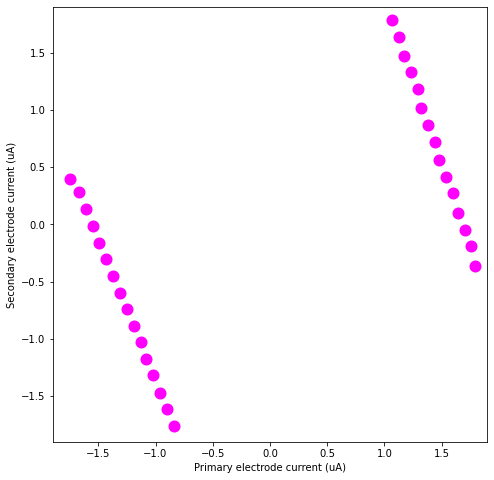

In [178]:
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
# color_map = ['black' if x == 0 else 'red' for x in spikes] 

# # fix the polarity to match jepson figure
# i1_fix = [-x for x in i1]
# i2_fix = [-x for x in i2]

# Define the colormap
# cmap = plt.cm.get_cmap('RdBu')
cmap = plt.cm.get_cmap('coolwarm')

vmin = 166
vmax = 172
# vmin = 165
# vmax = 173

# # -------
# # Define the colormap and custom outlier color
# cmap = plt.cm.RdBu
# custom_outlier_color = 'cyan'

# # Create a custom colormap with an appended outlier color
# new_cmap = mcolors.ListedColormap(cmap(np.linspace(0, 1, cmap.N)))
# new_cmap = new_cmap(np.linspace(0, 1, cmap.N))
# new_cmap = np.vstack((new_cmap, mcolors.to_rgba(custom_outlier_color)))
# custom_cmap = mcolors.ListedColormap(new_cmap)

# # Define the norm with boundaries to include the outlier
# # vmin = 156
# # vmax = 182
# vmin = 165
# vmax = 173
# bounds = np.linspace(vmin, vmax, cmap.N)
# bounds = np.append(bounds, [vmax + 10])  # Add an extra boundary for the outlier color
# norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)
# # -------


# ax.scatter(i1,i2,c=color_map,s=50,alpha=0.5)
# sc = ax.scatter(i1_fix,i2_fix,c=COM,cmap=cmap,vmin=vmin,vmax=vmax,s=100,alpha=0.5)
# sc = ax.scatter(i1,i2,c=COM,cmap=cmap,vmin=vmin,vmax=vmax,s=100,alpha=0.7)
sc = ax.scatter(i1,i2,s=100,c='magenta',edgecolors='magenta',linewidth=2)
# sc = ax.scatter(i1,i2,c=COM,cmap=custom_cmap,vmin=vmin,vmax=vmax,s=100,alpha=1)

ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_ylabel('Secondary electrode current (uA)')

# ax.set_xlim([-3,3])
# ax.set_ylim([-3,3])
ax.set_xlim([-1.9,1.9])
ax.set_ylim([-1.9,1.9])




# plt.savefig("axonalPerp-bielec-simResponse.pdf",format="pdf", bbox_inches="tight")
